In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

## **1. Load Dataset**

In [2]:
energy_df = pd.read_csv("ENB2012_data.csv")
energy_df.head(10)

,X1,X2,X3,X4,X5,X6,X7,X8,Y1,Y2
0,0.98,514.5,294.0,110.25,7.0,2,0.0,0,15.55,21.33
1,0.98,514.5,294.0,110.25,7.0,3,0.0,0,15.55,21.33
2,0.98,514.5,294.0,110.25,7.0,4,0.0,0,15.55,21.33
3,0.98,514.5,294.0,110.25,7.0,5,0.0,0,15.55,21.33
4,0.90,563.5,318.5,122.50,7.0,2,0.0,0,20.84,28.28
5,0.90,563.5,318.5,122.50,7.0,3,0.0,0,21.46,25.38
6,0.90,563.5,318.5,122.50,7.0,4,0.0,0,20.71,25.16
7,0.90,563.5,318.5,122.50,7.0,5,0.0,0,19.68,29.60
8,0.86,588.0,294.0,147.00,7.0,2,0.0,0,19.50,27.30
9,0.86,588.0,294.0,147.00,7.0,3,0.0,0,19.95,21.97


In [4]:
energy_df = energy_df.rename(columns={
    # Features
    'X1': 'relative_compactness', # Compactness ratio (surface area/volume)
    'X2': 'surface_area',         # Total surface area (m²)
    'X3': 'wall_area',            # Wall surface area (m²)
    'X4': 'roof_area',            # Roof surface area (m²)
    'X5': 'overall_height',       # Building height (m)
    'X6': 'orientation',          # Building orientation (2-5, categorical)
    'X7': 'glazing_area',         # Window/glazing area ratio (0-0.4)
    'X8': 'glazing_distribution', # Window distribution pattern (0-5)

    # Targets
    'Y1': 'heating_load',         # Heating energy load (kWh/m²)
    'Y2': 'cooling_load'          # Cooling energy load (kWh/m²)
})

energy_df.head(10)

,relative_compactness,surface_area,wall_area,roof_area,overall_height,orientation,glazing_area,glazing_distribution,heating_load,cooling_load
0,0.98,514.5,294.0,110.25,7.0,2,0.0,0,15.55,21.33
1,0.98,514.5,294.0,110.25,7.0,3,0.0,0,15.55,21.33
2,0.98,514.5,294.0,110.25,7.0,4,0.0,0,15.55,21.33
3,0.98,514.5,294.0,110.25,7.0,5,0.0,0,15.55,21.33
4,0.90,563.5,318.5,122.50,7.0,2,0.0,0,20.84,28.28
5,0.90,563.5,318.5,122.50,7.0,3,0.0,0,21.46,25.38
6,0.90,563.5,318.5,122.50,7.0,4,0.0,0,20.71,25.16
7,0.90,563.5,318.5,122.50,7.0,5,0.0,0,19.68,29.60
8,0.86,588.0,294.0,147.00,7.0,2,0.0,0,19.50,27.30
9,0.86,588.0,294.0,147.00,7.0,3,0.0,0,19.95,21.97


## **2. Multicollinearity Resolution**

In [5]:
def create_comprehensive_features(df):
    df = energy_df.copy()

    # Surface-to-Roof ratio (multi-story indicator: high = more floors)
    df['envelope_surface_ratio'] = df['surface_area'] / df['roof_area'].replace(0, np.nan)

    # Wall-to-Roof ratio (thermal envelope distribution)
    df['wall_roof_ratio'] = df['wall_area'] / df['roof_area'].replace(0, np.nan)

    # Surface-to-Volume ratio (heat loss efficiency metric)
    df['surface_to_volume'] = df['surface_area'] / (df['roof_area'] * df['overall_height']).replace(0, np.nan)

    # Aspect Ratio (Height² / Roof Area): Tall=high, Sprawled=low
    df['aspect_efficiency'] = df['overall_height']**2 / df['roof_area'].replace(0, np.nan)

    return df

energy_df = create_comprehensive_features(energy_df)

In [6]:
energy_df.head(10)

,relative_compactness,surface_area,wall_area,roof_area,overall_height,orientation,glazing_area,glazing_distribution,heating_load,cooling_load,envelope_surface_ratio,wall_roof_ratio,surface_to_volume,aspect_efficiency
0,0.98,514.5,294.0,110.25,7.0,2,0.0,0,15.55,21.33,4.666667,2.666667,0.666667,0.444444
1,0.98,514.5,294.0,110.25,7.0,3,0.0,0,15.55,21.33,4.666667,2.666667,0.666667,0.444444
2,0.98,514.5,294.0,110.25,7.0,4,0.0,0,15.55,21.33,4.666667,2.666667,0.666667,0.444444
3,0.98,514.5,294.0,110.25,7.0,5,0.0,0,15.55,21.33,4.666667,2.666667,0.666667,0.444444
4,0.90,563.5,318.5,122.50,7.0,2,0.0,0,20.84,28.28,4.600000,2.600000,0.657143,0.400000
5,0.90,563.5,318.5,122.50,7.0,3,0.0,0,21.46,25.38,4.600000,2.600000,0.657143,0.400000
6,0.90,563.5,318.5,122.50,7.0,4,0.0,0,20.71,25.16,4.600000,2.600000,0.657143,0.400000
7,0.90,563.5,318.5,122.50,7.0,5,0.0,0,19.68,29.60,4.600000,2.600000,0.657143,0.400000
8,0.86,588.0,294.0,147.00,7.0,2,0.0,0,19.50,27.30,4.000000,2.000000,0.571429,0.333333
9,0.86,588.0,294.0,147.00,7.0,3,0.0,0,19.95,21.97,4.000000,2.000000,0.571429,0.333333


## **3. Split Train/Val/Test first to prevents data leakage**

In [7]:
X = energy_df.drop(columns=['heating_load', 'cooling_load'])
y = energy_df[['heating_load', 'cooling_load']]

In [8]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [9]:
print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

X_train shape: (614, 12)
X_test shape: (154, 12)
y_train shape: (614, 2)
y_test shape: (154, 2)


## **Feature Engineering on 'Training data' only**

## **4. Missing values**

In [10]:
print("X_train dataset:")
print(X_train.isnull().sum())

print("\nX_test dataset:")
print(X_test.isnull().sum())

print("\ny_train dataset:")
print(y_train.isnull().sum())

print("\ny_test dataset:")
print(y_test.isnull().sum())

X_train dataset:
relative_compactness      0
surface_area              0
wall_area                 0
roof_area                 0
overall_height            0
orientation               0
glazing_area              0
glazing_distribution      0
envelope_surface_ratio    0
wall_roof_ratio           0
surface_to_volume         0
aspect_efficiency         0
dtype: int64

X_test dataset:
relative_compactness      0
surface_area              0
wall_area                 0
roof_area                 0
overall_height            0
orientation               0
glazing_area              0
glazing_distribution      0
envelope_surface_ratio    0
wall_roof_ratio           0
surface_to_volume         0
aspect_efficiency         0
dtype: int64

y_train dataset:
heating_load    0
cooling_load    0
dtype: int64

y_test dataset:
heating_load    0
cooling_load    0
dtype: int64


## **5. Outliers**

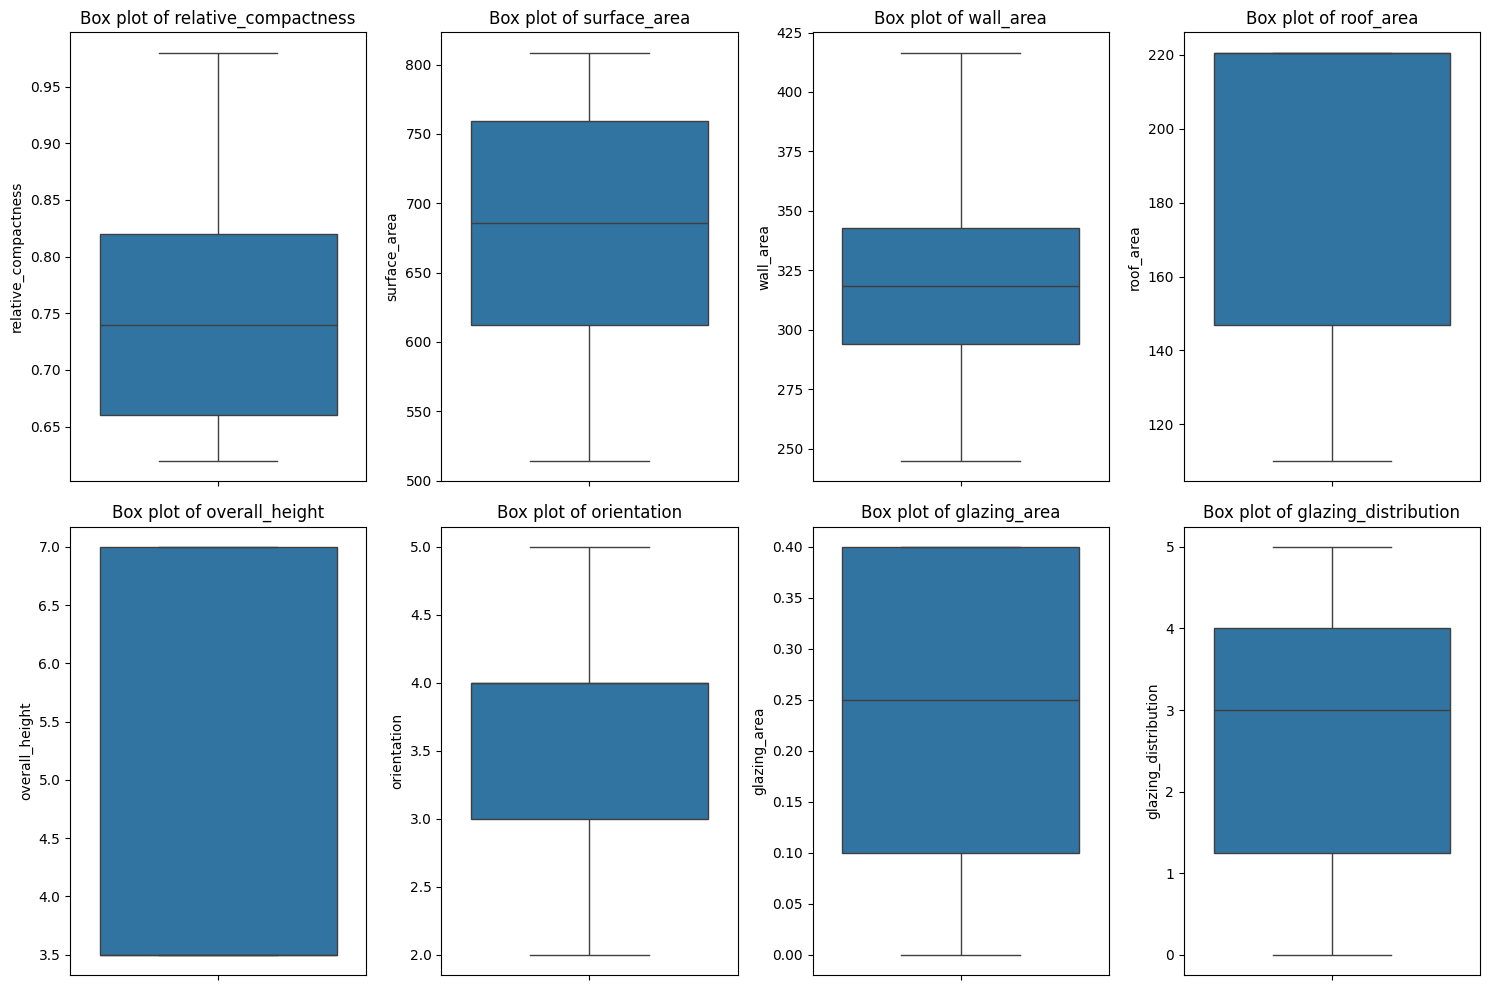

In [11]:
numerical_cols = ['relative_compactness', 'surface_area', 'wall_area', 'roof_area', 'overall_height', 'orientation', 'glazing_area', 'glazing_distribution']

plt.figure(figsize=(15, 10))
for i, col in enumerate(numerical_cols):
  plt.subplot(2, 4, i + 1)
  sns.boxplot(data=X_train, y=col)
  plt.title(f'Box plot of {col}')

plt.tight_layout()
plt.show()

## **6. Scale Features**

In [12]:
# Initialize the StandardScaler
scaler = StandardScaler()

# Apply to train data
X_train[['relative_compactness', 'surface_area', 'wall_area', 'roof_area', 'envelope_surface_ratio', 'wall_roof_ratio', 'surface_to_volume', 'aspect_efficiency']] = scaler.fit_transform(
    X_train[['relative_compactness', 'surface_area', 'wall_area', 'roof_area', 'envelope_surface_ratio', 'wall_roof_ratio', 'surface_to_volume', 'aspect_efficiency']]
)

# Apply same scaling to test data
X_test[['relative_compactness', 'surface_area', 'wall_area', 'roof_area', 'envelope_surface_ratio', 'wall_roof_ratio', 'surface_to_volume', 'aspect_efficiency']] = scaler.transform(
    X_test[['relative_compactness', 'surface_area', 'wall_area', 'roof_area', 'envelope_surface_ratio', 'wall_roof_ratio', 'surface_to_volume', 'aspect_efficiency']]
)

## **7. Feature selection**

In [13]:
# Create a copy of training data for feature selection
# This way we can keep original X_train safe
X_train_for_selection = X_train.copy()
X_train_for_selection[['Y1', 'Y2']] = y_train.values

# Calculate correlations
correlation_with_targets = X_train_for_selection.corr(numeric_only=True)[['Y1', 'Y2']].drop(['Y1', 'Y2']).sort_values(by='Y1', ascending=False)

print("Correlation of features with 'Y1' & 'Y2':")
display(correlation_with_targets)

Correlation of features with 'Y1' & 'Y2':


,Y1,Y2
overall_height,0.889154,0.894927
aspect_efficiency,0.870122,0.872386
wall_roof_ratio,0.843083,0.830611
envelope_surface_ratio,0.843083,0.830611
relative_compactness,0.629314,0.642148
wall_area,0.439092,0.410905
glazing_area,0.276184,0.212642
glazing_distribution,0.080206,0.041308
orientation,0.001772,0.008773
surface_area,-0.664684,-0.679988


In [14]:
selected_features = correlation_with_targets[abs(correlation_with_targets) > 0.01].index.tolist()

# Ensure the selected features are in the original order of X_train
original_x_train_cols = X_train.columns.tolist()
selected_features_ordered = [col for col in original_x_train_cols if col in selected_features]

print(f"\nFeatures selected based on absolute correlation > 0.01 with 'Y1' & Y2:\n{selected_features_ordered}")

# Apply feature selection to training data
X_train_selected = X_train[selected_features_ordered]

# Apply same feature selection to test data
X_test_selected = X_test[selected_features_ordered]


Features selected based on absolute correlation > 0.01 with 'Y1' & Y2:
['relative_compactness', 'surface_area', 'wall_area', 'roof_area', 'overall_height', 'orientation', 'glazing_area', 'glazing_distribution', 'envelope_surface_ratio', 'wall_roof_ratio', 'surface_to_volume', 'aspect_efficiency']


# **8. Save the new (preprocessed) train and test datasets**

In [16]:
# Save processed training data
X_train_selected.to_csv('X_train_processed.csv', index=False)
y_train.to_csv('y_train.csv', index=False)

# Save test data
X_test_selected.to_csv('X_test.csv', index=False)
y_test.to_csv('y_test.csv', index=False)

print("All processed datasets saved")

All processed datasets saved


In [ ]:
import joblib  # Better than pickle for large objects

# Save scaler right after fitting it
joblib.dump(scaler, "scaler.pkl")
print("Scaler saved to scaler.pkl")

Scaler saved to scaler.pkl
